In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [34]:
#Load Data
df = pd.read_csv("cirrhosis.csv")

In [37]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape : {df.shape}")
print(f"\nFirst 5 rows: \n{df.head()}")
print(f"\nData types: \n{df.dtypes}")
print(f"\nMissing values per column: \n{df.isnull().sum()}")
print(f"\nBasic statistics: \n{df.describe()}")

DATASET OVERVIEW
Shape : (418, 20)

First 5 rows: 
   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin 

In [38]:
#Data cleaning & processing
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

In [39]:
target_map = {"C": 0, "CL": 1, "D": 2}
df["Status"] = df["Status"].map(target_map)

In [40]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "Status"]
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumerical columns : {num_cols}")
print(f"Categorical columns: {cat_cols}")


Numerical columns : ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Categorical columns: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


In [41]:
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\nMissing values after imputation:\n{df.isnull().sum().sum()} total")


Missing values after imputation:
0 total


In [44]:
def cap_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in num_cols:
    df[col] = cap_outliers_iqr(df[col])

In [47]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nData after cleaning (first 5 rows):")
print(df.head())


Data after cleaning (first 5 rows):
   N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  Edema  \
0     400       2     0  21464    0        1             1        1      2   
1    4500       0     0  20617    0        0             1        1      0   
2    1012       2     0  25594    1        0             0        0      1   
3    1925       2     0  19994    0        0             1        1      1   
4    1504       1     1  13918    0        0             1        1      0   

   Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  Tryglicerides  \
0        7.3        261.0     2.60   156.0    1718.0  137.95          172.0   
1        1.1        302.0     4.14    54.0    2745.0  113.52           88.0   
2        1.4        176.0     3.48   175.0     516.0   96.10           55.0   
3        1.8        244.0     2.54    64.0    2745.0   60.63           92.0   
4        3.4        279.0     3.53   143.0     671.0  113.15           72.0   

   Platelets  Proth

In [48]:
#EDA
sns.set_style("whitegrid")
PALETTE = ["#2196F3", "#FF5722", "#4CAF50"]

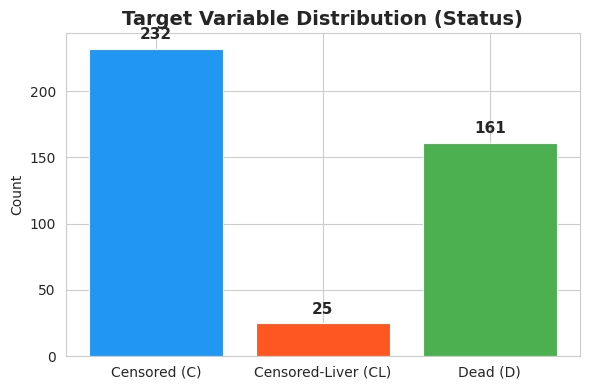

Saved: 01_target_distribution.png


In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
status_labels = {0: "Censored (C)", 1: "Censored-Liver (CL)", 2: "Dead (D)"}
counts = df["Status"].value_counts().sort_index()
bars = ax.bar(
    [status_labels[i] for i in counts.index],
    counts.values,
    color=PALETTE, edgecolor="white", linewidth=0.8
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Target Variable Distribution (Status)", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150)
plt.show()
print("Saved: 01_target_distribution.png")

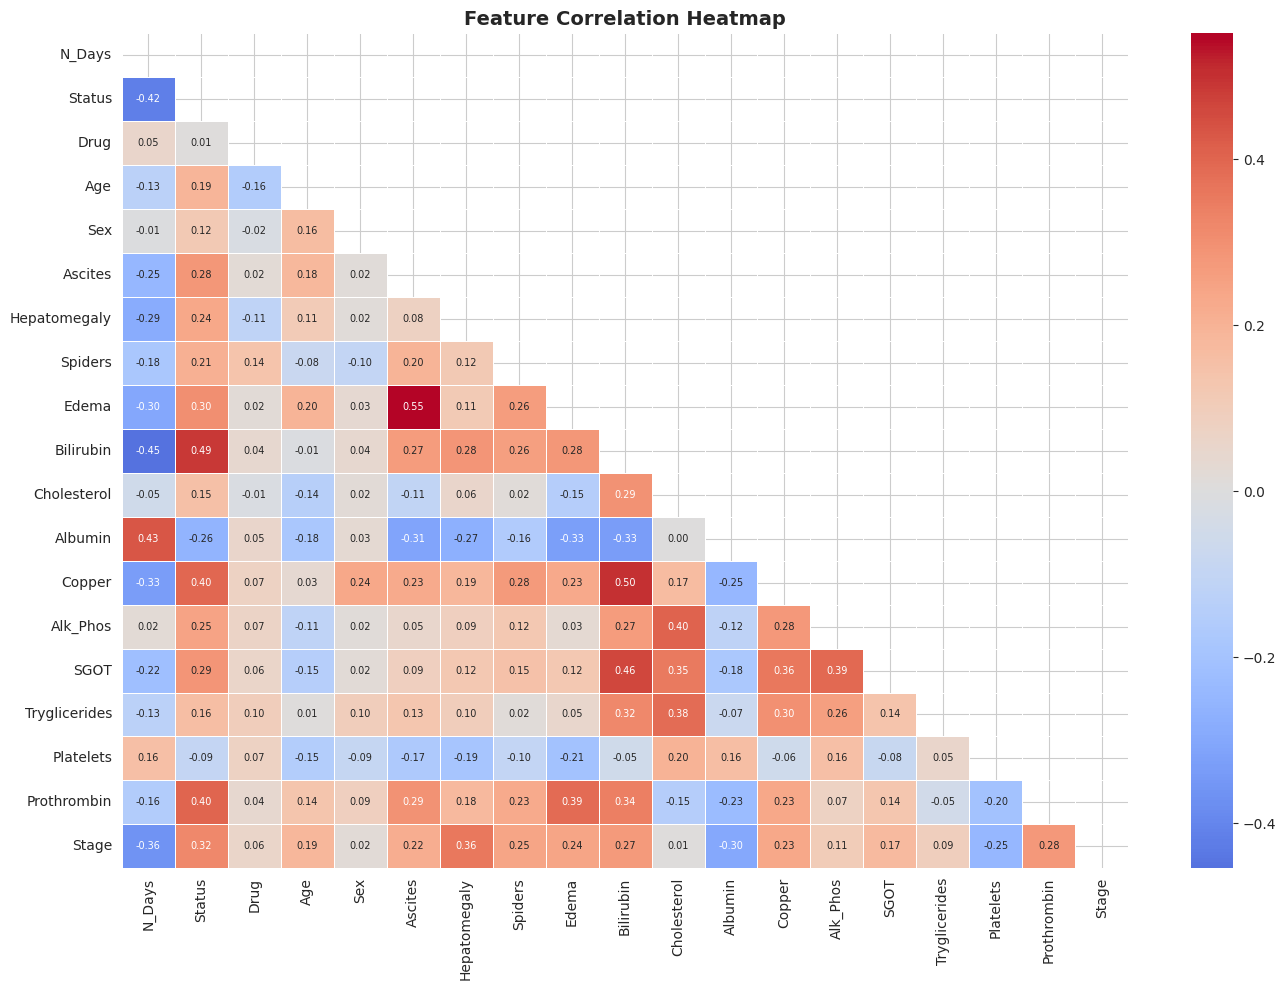

Saved: 02_correlation_heatmap.png


In [50]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: 02_correlation_heatmap.png")

In [52]:
key_features = ["N_Days", "Age", "Bilirubin", "Albumin",
                "Copper", "Prothrombin", "Platelets"]
key_features = [f for f in key_features if f in df.columns]

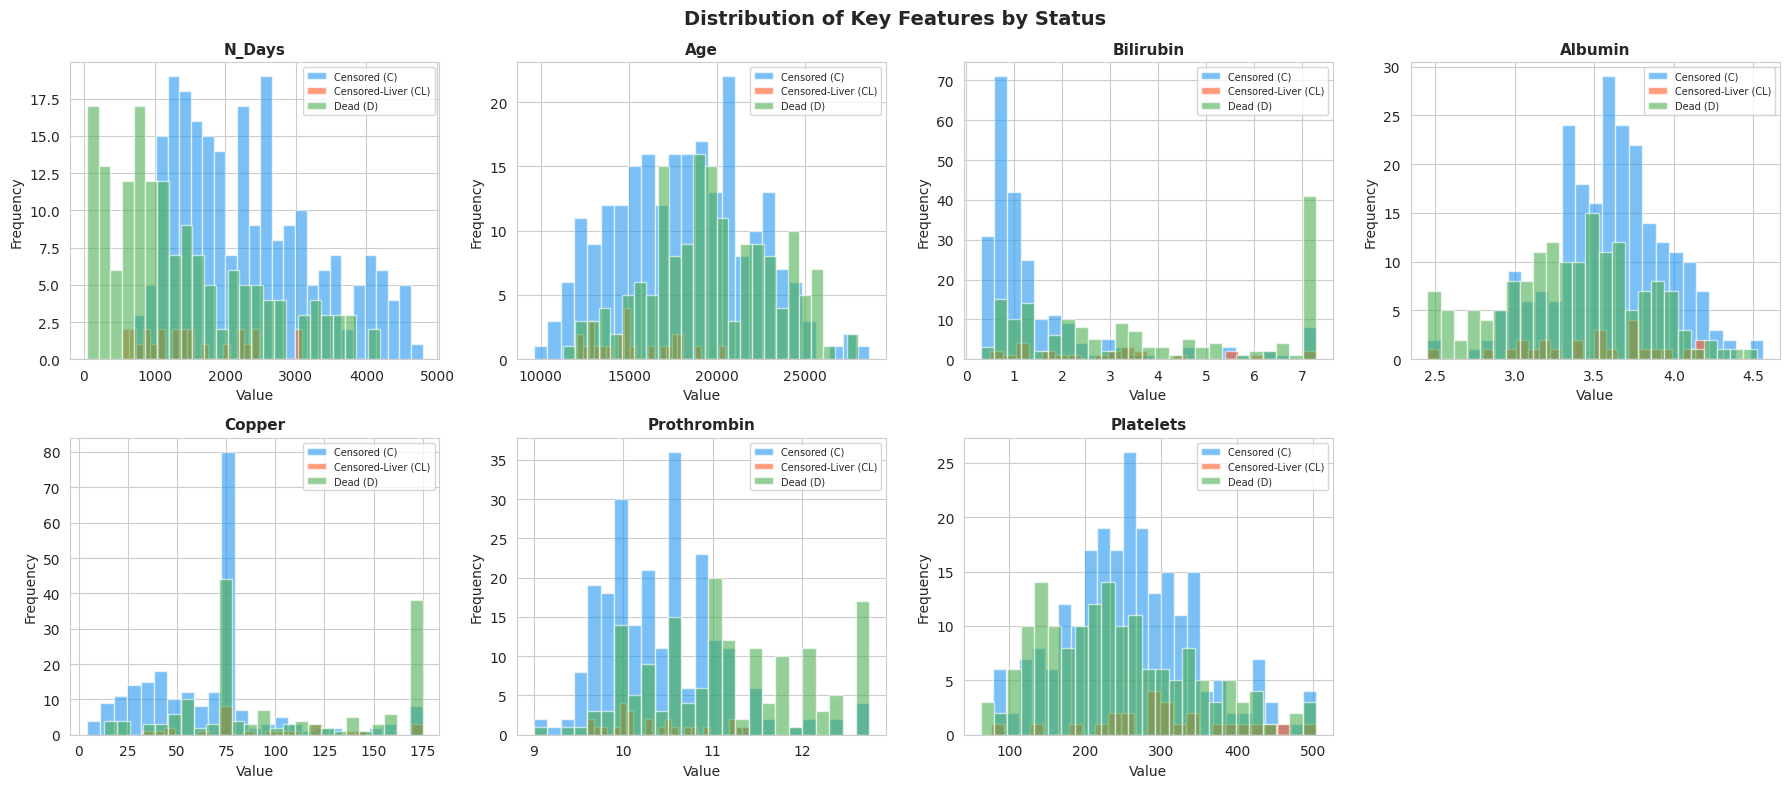

Saved: 03_feature_distributions.png


In [55]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    for status, color in zip([0, 1, 2], PALETTE):
        subset = df[df["Status"] == status][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label=status_labels[status], edgecolor="white")
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=7)
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribution of Key Features by Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("03_feature_distributions.png", dpi=150)
plt.show()
print("Saved: 03_feature_distributions.png")

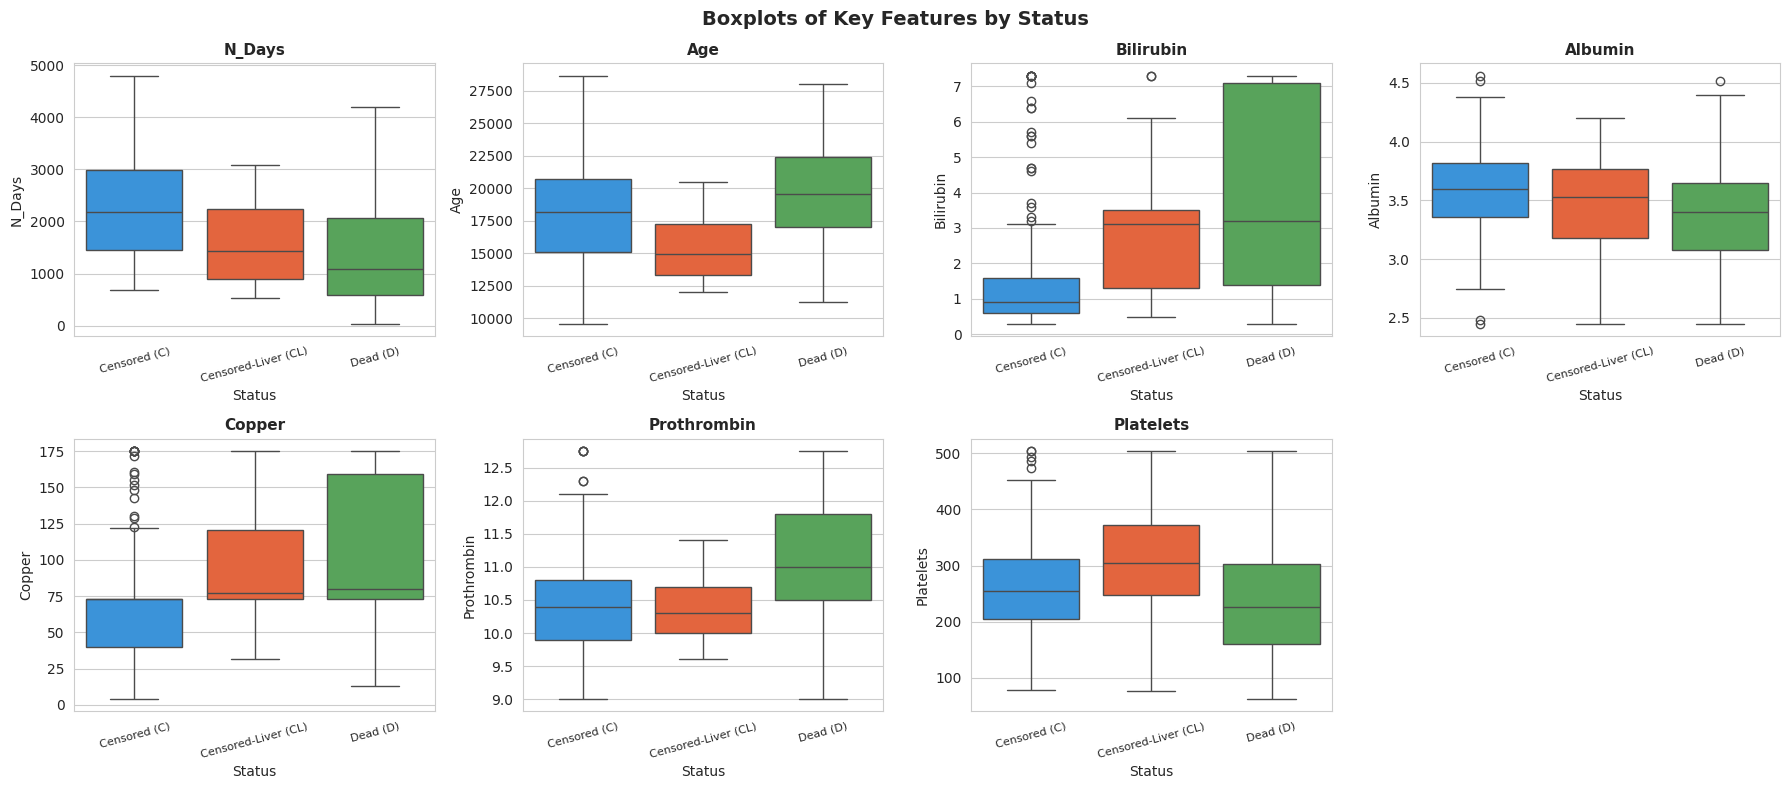

Saved: 04_boxplots.png


In [57]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    sns.boxplot(x="Status", y=feat, data=df, ax=axes[i], palette=PALETTE)
    axes[i].set_xticklabels([status_labels[j] for j in sorted(df["Status"].unique())],
                             rotation=15, fontsize=8)
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplots of Key Features by Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("04_boxplots.png", dpi=150)
plt.show()
print("Saved: 04_boxplots.png")

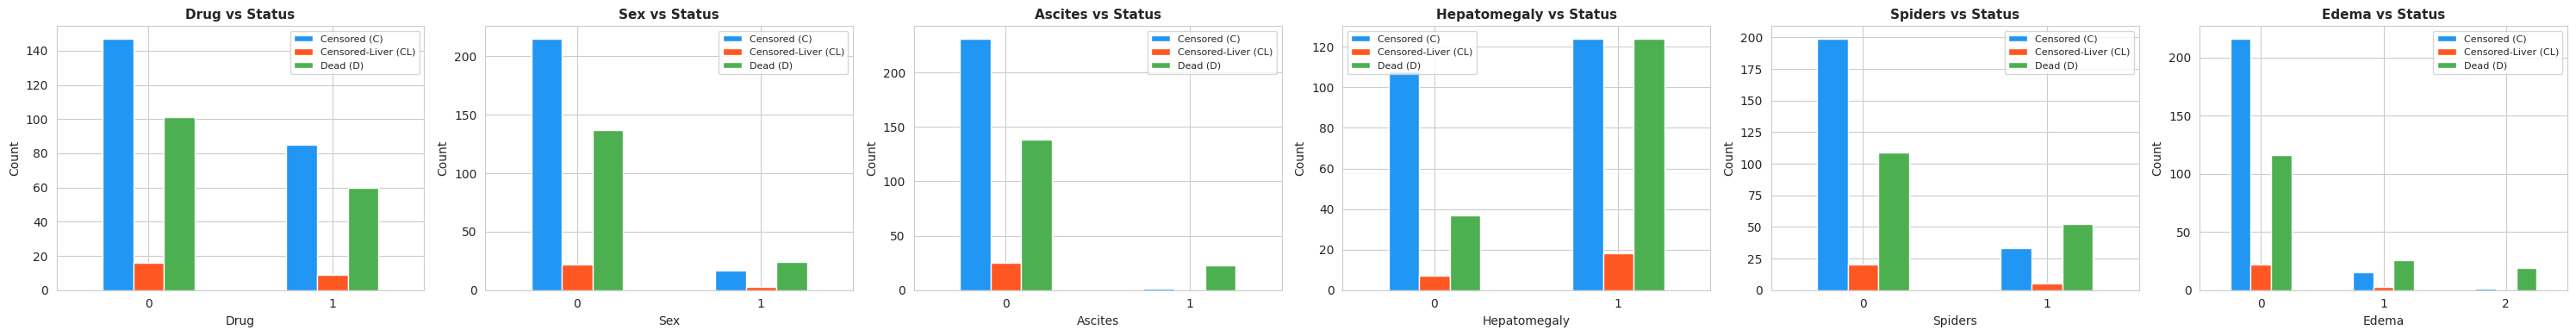

Saved: 05_categorical_vs_status.png


In [58]:
cat_encoded = [c for c in cat_cols if c in df.columns]
if cat_encoded:
    fig, axes = plt.subplots(1, len(cat_encoded), figsize=(5 * len(cat_encoded), 4))
    if len(cat_encoded) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_encoded):
        cross = pd.crosstab(df[col], df["Status"])
        cross.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white")
        ax.set_title(f"{col} vs Status", fontsize=11, fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.legend([status_labels[i] for i in sorted(df["Status"].unique())], fontsize=8)
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig("05_categorical_vs_status.png", dpi=150)
    plt.show()
    print("Saved: 05_categorical_vs_status.png")

In [59]:
X = df.drop(columns=["Status"])
y = df["Status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\nFeature matrix shape : {X_scaled.shape}")
print(f"Target distribution  :\n{y.value_counts().sort_index()}")


Feature matrix shape : (418, 18)
Target distribution  :
Status
0    232
1     25
2    161
Name: count, dtype: int64


In [60]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric="mlogloss",
        random_state=42, n_jobs=-1
    )
}

cv_results = {}
print("\n" + "=" * 60)
print("STRATIFIED 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=skf,
                             scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"  Fold Accuracies : {np.round(scores, 4)}")
    print(f"  Mean ± Std      : {scores.mean():.4f} ± {scores.std():.4f}")


STRATIFIED 5-FOLD CROSS-VALIDATION RESULTS

Random Forest
  Fold Accuracies : [0.7381 0.7738 0.7738 0.8072 0.6747]
  Mean ± Std      : 0.7535 ± 0.0451

XGBoost
  Fold Accuracies : [0.7381 0.7619 0.7381 0.8313 0.6867]
  Mean ± Std      : 0.7512 ± 0.0470


In [61]:
last_train_idx, last_test_idx = list(skf.split(X_scaled, y))[-1]
X_train = X_scaled.iloc[last_train_idx]
X_test  = X_scaled.iloc[last_test_idx]
y_train = y.iloc[last_train_idx]
y_test  = y.iloc[last_test_idx]

print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION ")
print("=" * 60)

trained_models = {}
predictions    = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    predictions[name]    = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(
        y_test, y_pred,
        target_names=[status_labels[i] for i in sorted(y.unique())],
        zero_division=0
    ))


FINAL MODEL EVALUATION 

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  Accuracy  : 0.6747
  Precision : 0.6430
  Recall    : 0.6747

  Classification Report:

                     precision    recall  f1-score   support

       Censored (C)       0.68      0.83      0.75        46
Censored-Liver (CL)       0.00      0.00      0.00         5
           Dead (D)       0.69      0.56      0.62        32

           accuracy                           0.67        83
          macro avg       0.46      0.46      0.46        83
       weighted avg       0.64      0.67      0.65        83


────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  Accuracy  : 0.6867
  Precision : 0.6568
  Recall    : 0.6867

  Classification Report:

                     precision    recall  f1-score   support

       Censored (C)       0.68      0.85      0.76        46
Censored-Liver (CL)       0.00      0.00      0.00

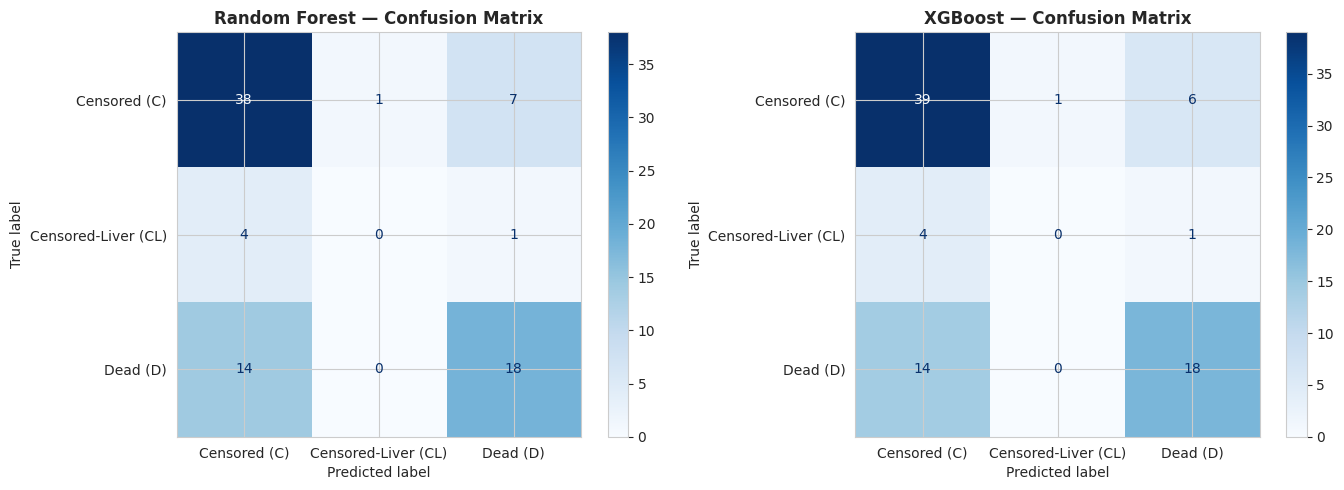

Saved: 06_confusion_matrices.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_names_list = [status_labels[i] for i in sorted(y.unique())]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=target_names_list)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("06_confusion_matrices.png", dpi=150)
plt.show()
print("Saved: 06_confusion_matrices.png")

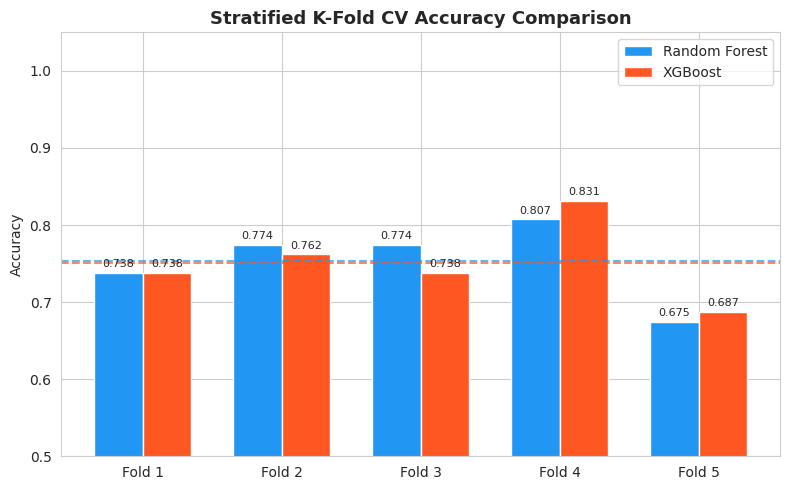

Saved: 07_cv_comparison.png


In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
fold_labels = [f"Fold {i+1}" for i in range(5)]
x = np.arange(len(fold_labels))
width = 0.35

bars1 = ax.bar(x - width/2, cv_results["Random Forest"], width,
               label="Random Forest", color="#2196F3", edgecolor="white")
bars2 = ax.bar(x + width/2, cv_results["XGBoost"], width,
               label="XGBoost", color="#FF5722", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Stratified K-Fold CV Accuracy Comparison", fontsize=13, fontweight="bold")
ax.legend()
ax.axhline(np.mean(cv_results["Random Forest"]), color="#2196F3",
           linestyle="--", alpha=0.7, linewidth=1.5)
ax.axhline(np.mean(cv_results["XGBoost"]), color="#FF5722",
           linestyle="--", alpha=0.7, linewidth=1.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("07_cv_comparison.png", dpi=150)
plt.show()
print("Saved: 07_cv_comparison.png")

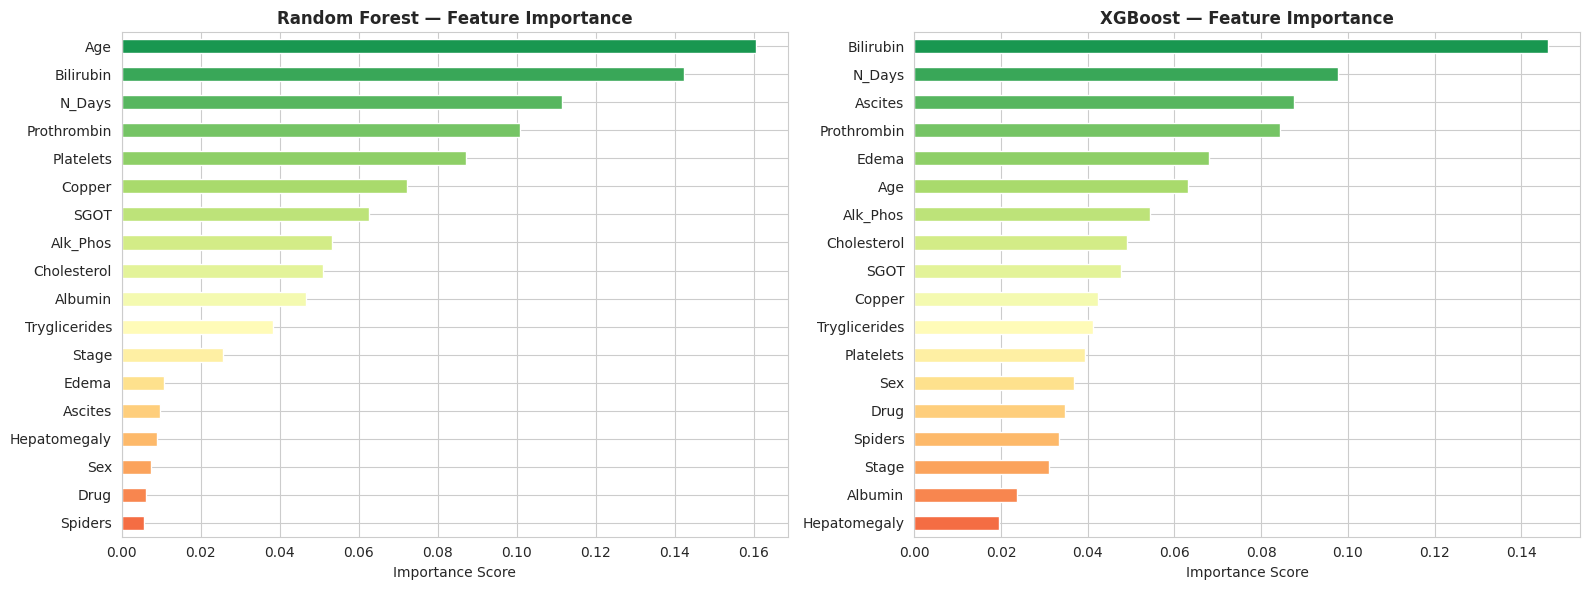

Saved: 08_feature_importance.png


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feature_names = X.columns.tolist()

for ax, (name, model) in zip(axes, trained_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
    importances.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_title(f"{name} — Feature Importance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("08_feature_importance.png", dpi=150)
plt.show()
print("Saved: 08_feature_importance.png")

In [72]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
summary = []
for name, y_pred in predictions.items():
    summary.append({
        "Model"           : name,
        "CV Mean Accuracy": f"{cv_results[name].mean():.4f}",
        "CV Std"          : f"{cv_results[name].std():.4f}",
        "Test Accuracy"   : f"{accuracy_score(y_test, y_pred):.4f}",
        "Test Precision"  : f"{precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}",
        "Test Recall"     : f"{recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}",
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print("\nAll plots saved.")



FINAL SUMMARY
        Model CV Mean Accuracy CV Std Test Accuracy Test Precision Test Recall
Random Forest           0.7535 0.0451        0.6747         0.6430      0.6747
      XGBoost           0.7512 0.0470        0.6867         0.6568      0.6867

All plots saved.
